# Imports

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
# from src.gmm import GMM,CovarianceType

In [2]:
from google.colab import files

uploaded = files.upload()
from gmm import GMM,CovarianceType

Saving gmm.py to gmm.py


## Load the breast cancer dataset

In [3]:
dataset = load_breast_cancer()
X=dataset.data
y=dataset.target

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {dataset.feature_names}")
print(f"\nClass distribution:")
print(f"Class 0 (malignant): {np.sum(y == 0)}")
print(f"Class 1 (benign): {np.sum(y == 1)}")

Dataset Information:
Number of samples: 569
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Class distribution:
Class 0 (malignant): 212
Class 1 (benign): 357


In [4]:
# Check for missing values
print(f"Missing values: {np.isnan(X).sum()}")  # Should be 0

Missing values: 0


### Standarize the data

In [5]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero for constant features
    std[std == 0] = 1

    X_scaled = (X - mean) / std

    return X_scaled, mean, std

In [6]:
# Standardize
X_scaled, mean, std = standardize(X)

print(f"Original - Mean: {X.mean():.2f}, Std: {X.std():.2f}")
print(f"Scaled   - Mean: {X_scaled.mean():.2f}, Std: {X_scaled.std():.2f}")

Original - Mean: 61.89, Std: 228.30
Scaled   - Mean: -0.00, Std: 1.00


### Data Splitting

In [7]:
X_train,X_temp,y_train,y_temp=train_test_split(X_scaled,y,test_size=0.30,stratify=y,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.50,stratify=y_temp,random_state=42)

print(X_train.shape)
print(y_train.shape)

(398, 30)
(398,)


### Hyperparameter Tuning

In [8]:
n_components_range = range(2, 5)
covariance_types = [CovarianceType.FULL, CovarianceType.TIED,
                    CovarianceType.DIAGONAL, CovarianceType.SPHERICAL]

results={}

### Train

In [9]:
for cov_type in covariance_types:
    print(f"\n{'='*50}")
    print(f"Testing {cov_type.value} covariance")
    print(f"{'='*50}")

    bic_scores = []
    aic_scores = []

    for n_components in n_components_range:
        print(f"  n_components={n_components}...", end=" ")

        # Fit GMM
        gmm = GMM(n_components=n_components,
                  cov_type=cov_type,
                  tol=1e-3,
                  max_iter=70,
                  reg_covar=1e-3)
        gmm.fit(X_scaled)

        # Compute BIC and AIC
        bic = gmm.bic(X_scaled)
        aic = gmm.aic(X_scaled)

        bic_scores.append(bic)
        aic_scores.append(aic)

        print(f"BIC: {bic:.2f}, AIC: {aic:.2f}, Converged in {len(gmm.log_likelihoods)} iterations")

    results[cov_type.value] = {
        'bic': bic_scores,
        'aic': aic_scores
    }



Testing full covariance
  n_components=2... Converged at iteration 66
BIC: 9639.69, AIC: 5334.91, Converged in 67 iterations
  n_components=3... Converged at iteration 51
BIC: 9451.08, AIC: 2991.73, Converged in 52 iterations
  n_components=4... BIC: 9960.13, AIC: 1346.21, Converged in 70 iterations

Testing tied covariance
  n_components=2... Converged at iteration 13
BIC: 12994.61, AIC: 10709.73, Converged in 14 iterations
  n_components=3... BIC: 13292.81, AIC: 10873.26, Converged in 70 iterations
  n_components=4... BIC: 13573.16, AIC: 11018.96, Converged in 70 iterations

Testing diag covariance
  n_components=2... Converged at iteration 19
BIC: 37877.15, AIC: 37351.54, Converged in 20 iterations
  n_components=3... Converged at iteration 29
BIC: 35779.60, AIC: 34989.01, Converged in 30 iterations
  n_components=4... Converged at iteration 53
BIC: 35546.93, AIC: 34491.37, Converged in 54 iterations

Testing spherical covariance
  n_components=2... Converged at iteration 20
BIC: 4

### Plot the results

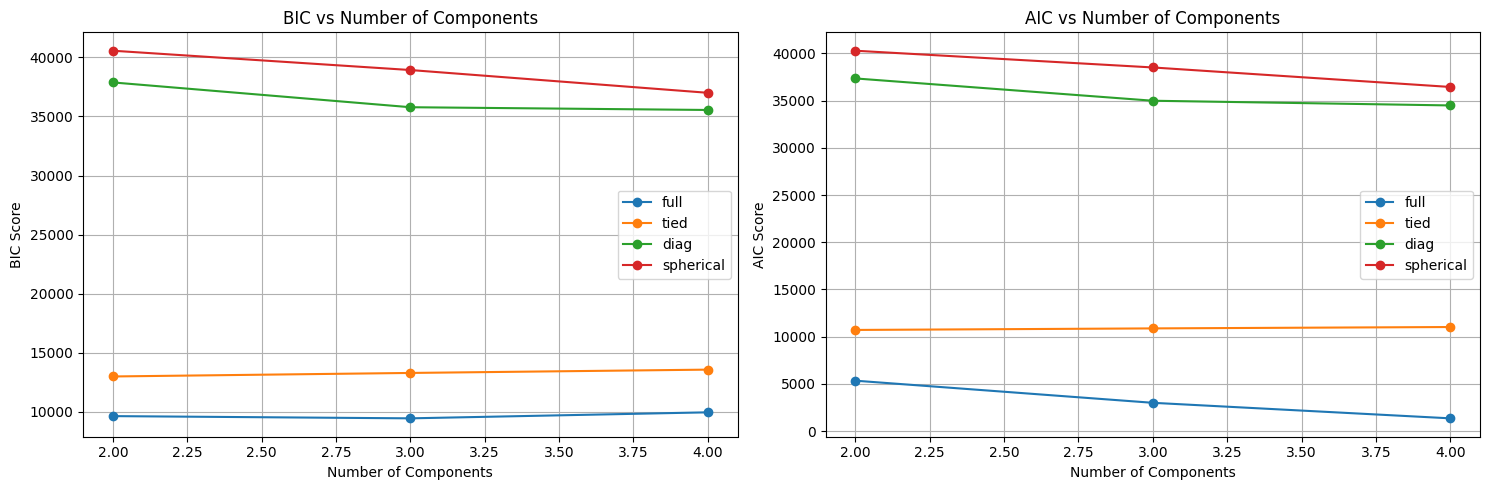

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for cov_type in covariance_types:
    ax1.plot(n_components_range, results[cov_type.value]['bic'],
             marker='o', label=cov_type.value)
    ax2.plot(n_components_range, results[cov_type.value]['aic'],
             marker='o', label=cov_type.value)

ax1.set_xlabel('Number of Components')
ax1.set_ylabel('BIC Score')
ax1.set_title('BIC vs Number of Components')
ax1.legend()
ax1.grid(True)

ax2.set_xlabel('Number of Components')
ax2.set_ylabel('AIC Score')
ax2.set_title('AIC vs Number of Components')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


### Find optimal configuration

In [11]:
print("\n" + "="*50)
print("OPTIMAL CONFIGURATIONS")
print("="*50)

for cov_type in covariance_types:
    bic_scores = results[cov_type.value]['bic']
    aic_scores = results[cov_type.value]['aic']

    optimal_bic = n_components_range[np.argmin(bic_scores)]
    optimal_aic = n_components_range[np.argmin(aic_scores)]

    print(f"\n{cov_type.value}:")
    print(f"  Optimal components (BIC): {optimal_bic}")
    print(f"  Optimal components (AIC): {optimal_aic}")


OPTIMAL CONFIGURATIONS

full:
  Optimal components (BIC): 3
  Optimal components (AIC): 4

tied:
  Optimal components (BIC): 2
  Optimal components (AIC): 2

diag:
  Optimal components (BIC): 4
  Optimal components (AIC): 4

spherical:
  Optimal components (BIC): 4
  Optimal components (AIC): 4


### Fit with optimal configuration

Converged at iteration 38


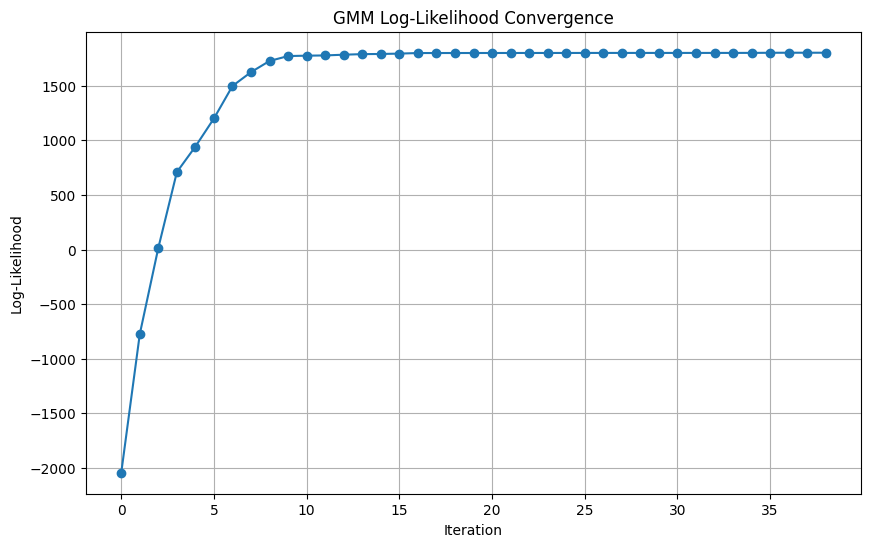

Final log-likelihood: 1802.34
Converged in 39 iterations


In [12]:

optimal_gmm = GMM(n_components=optimal_bic,
                  cov_type=CovarianceType.FULL,
                  tol=1e-3,
                  max_iter=100)
optimal_gmm.fit(X_scaled)

# Plot convergence
plt.figure(figsize=(10, 6))
plt.plot(optimal_gmm.log_likelihoods, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('GMM Log-Likelihood Convergence')
plt.grid(True)
plt.show()

print(f"Final log-likelihood: {optimal_gmm.log_likelihoods[-1]:.2f}")
print(f"Converged in {len(optimal_gmm.log_likelihoods)} iterations")